### Import

In [1]:
import sys
sys.path.insert(0, '../') 
import data_generation.SimulatorWaveEquation as simu
import numpy as np
from data_generation import DataPlotter as dp
import matplotlib.pyplot as plt
import os 
import GNN_model_startup.GNN as gnn
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
import torch.nn as nn
import pytorch_lightning as pl
import GNN_model_startup.autoregreesive_roll_out as autoregreesive_roll_out
import GNN_model_startup.onestep_rollout as onestep_rollout
import xarray as xr

c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Data definitions

In [2]:
R = 1 # Radius
C = 1 # Wave speed
Lmax = 10 # Maximum degree of spherical harmonics
tmax = 10 # Maximum time  
generations = 4 # level of refinement for the grid
x0,y0,z0 = R,R,R # Initial position of the gaussian pulse

#### Initial conditions

In [3]:

# Initial condition: Gaussian pulse centered at (x0, y0, z0)
def f_handle(x, y, z):
    # dot product with center
    dot = x*x0 + y*y0 + z*z0
    
    cos_alpha = np.clip(dot / R**2, -1.0, 1.0)

    alpha = np.arccos(cos_alpha)
     
    return np.exp(-(alpha**2) / (2*0.2**2))

# Initital condition: zero initial velocity
g_handle = lambda x, y, z: 0 * x

In [4]:
sim = simu.SimulatorWaveEquation(R=1.0, C=C, Lmax=Lmax, tmax=tmax, f_handle=f_handle, g_handle=g_handle, generations=generations)
print("clf ok:",sim.clf) # Check the CFL condition
print("clf val:",sim.clf_value)

clf ok: True
clf val: 0.700350381093758


In [5]:
title = f"wave_sphere_data_clf{sim.clf:.2f}"
ds = sim.simulate(title=title, savedata=True, savegraph=False)  # (time, N) 

In [6]:
nc_path = "../data/nc_files"
dataset = gnn.WaveData(data_path=os.path.join(nc_path, f"{title}.nc"))

# PyG DataLoader batches graphs automatically (no collate_fn needed)
loader = PyGDataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

Fin = 1
Fm = 64

phi = nn.Sequential(
    nn.Linear(2 * Fin, Fm),
    nn.ReLU(),
    nn.Linear(Fm, Fm),
)

psi = nn.Sequential(
    nn.Linear(Fin + Fm, Fm),
    nn.ReLU(),
    nn.Linear(Fm, Fin),
)

In [7]:
model = gnn.GNNModel(phi=phi, psi=psi, aggregate="mean", lr=1e-3)


In [ ]:
trainer = pl.Trainer(max_epochs=50)  # Early stopping can be added if needed
trainer.fit(model, loader) 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ phi  │ Sequential │  4.4 K │ train │     0 │
│ 1 │ psi  │ Sequential │  4.3 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 8.6 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.6 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\maria\OneDrive - Danmarks Tekniske 
Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` st

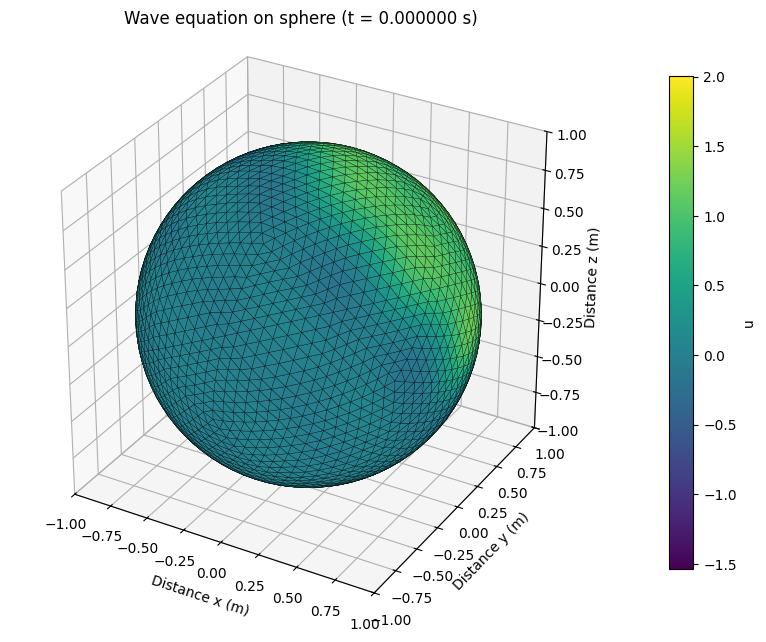

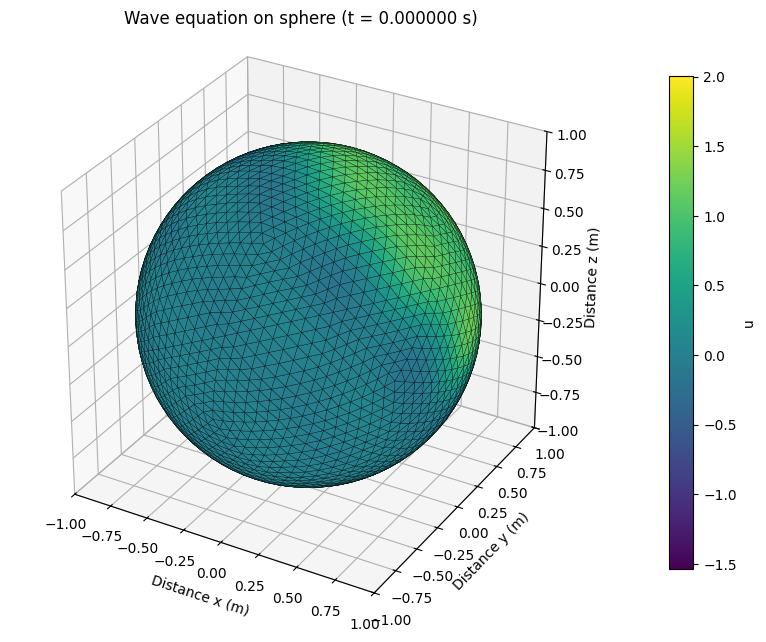

In [9]:
from matplotlib import cm, colors
# Load ground-truth data
ds = xr.open_dataset(os.path.join(nc_path, f"{title}.nc"))

ds_pred = autoregreesive_roll_out.autoregressive_rollout(model, ds, steps=200, device="cpu")

u_min = float(np.nanmin(ds["u"].values))
u_max = float(np.nanmax(ds["u"].values))
norm = colors.Normalize(vmin=u_min, vmax=u_max)
plot_true = dp.DataPlotter(ds=ds)
anim_true = plot_true.animate_sphere(norm=norm,out_path="true_test.gif", fps=15)

plot_pred = dp.DataPlotter(ds=ds_pred)
anim_pred = plot_pred.animate_sphere(norm=norm,out_path="pred_test.gif", fps=15)


Error should be 0 in initial condition

In [10]:
err0 = np.max(np.abs(ds_pred["u"].isel(time=0).values - ds["u"].isel(time=0).values))
print("max |pred0 - true0| =", err0)

max |pred0 - true0| = 5.959019300227908e-08


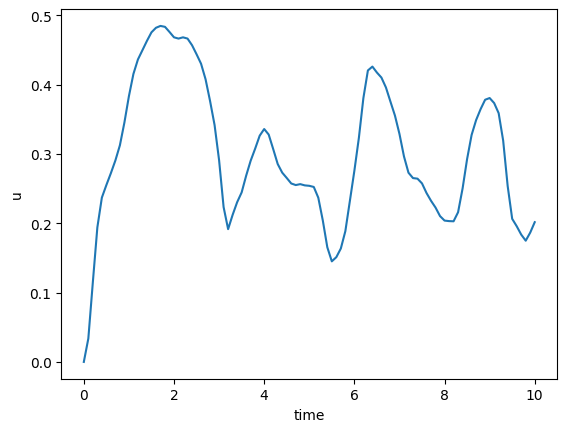

In [11]:
rmse_t = np.sqrt(((ds_pred["u"] - ds["u"])**2).mean("grid_index"))
rmse_t.plot()

In [12]:
from matplotlib import cm, colors
# Load ground-truth data
ds = xr.open_dataset(os.path.join(nc_path, f"{title}.nc"))

ds_pred = onestep_rollout.one_step_rollout(model, ds, steps=200, device="cpu")

u_min = float(np.nanmin(ds["u"].values))
u_max = float(np.nanmax(ds["u"].values))
norm = colors.Normalize(vmin=u_min, vmax=u_max)
plot_true = dp.DataPlotter(ds=ds)
anim_true = plot_true.animate_sphere(norm=norm,out_path="true_test_1step.gif", fps=15)
plt.close()
plot_pred = dp.DataPlotter(ds=ds_pred)
anim_pred = plot_pred.animate_sphere(norm=norm,out_path="pred_test_1step.gif", fps=15)
plt.close()

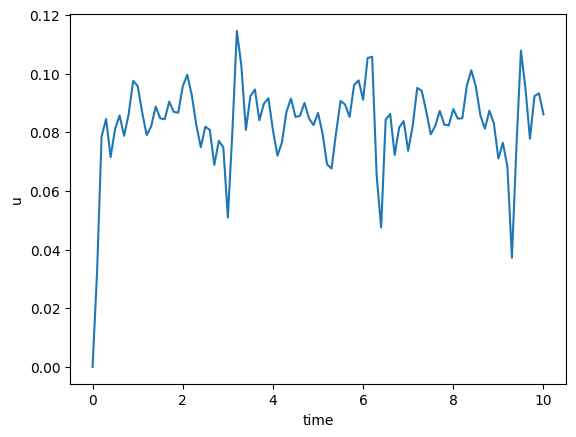

In [11]:
rmse_t = np.sqrt(((ds_pred["u"] - ds["u"])**2).mean("grid_index"))
rmse_t.plot()